# 01 - Train a Nim-Sum / XOR Predictor

This notebook trains a small two-layer neural network to predict the Nim balance:

```text
board state -> bit representation -> MLP with ReLU -> predicted XOR / Nim-sum bits
```

The notebook is configurable:

- `NUM_PILES`: number of piles
- `MAX_STONES`: maximum stones per pile
- `BIT_WIDTH`: computed from `MAX_STONES`

The trained model is saved to disk so the transformer move model can load it later.

In [1]:
from pathlib import Path
from dataclasses import dataclass, asdict
from itertools import product
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
@dataclass
class NimXorConfig:
    num_piles: int = 3
    max_stones: int = 7
    hidden_dim: int = 64
    batch_size: int = 64
    epochs: int = 600
    learning_rate: float = 0.01
    test_fraction: float = 0.2
    seed: int = 42
    checkpoint_path: str = "checkpoints/nim_xor_predictor.pt"

    @property
    def bit_width(self):
        return max(1, self.max_stones.bit_length())

    @property
    def input_dim(self):
        return self.num_piles * self.bit_width


CONFIG = NimXorConfig(num_piles=3, max_stones=7)
Path(CONFIG.checkpoint_path).parent.mkdir(parents=True, exist_ok=True)
CONFIG

NimXorConfig(num_piles=3, max_stones=7, hidden_dim=64, batch_size=64, epochs=600, learning_rate=0.01, test_fraction=0.2, seed=42, checkpoint_path='checkpoints/nim_xor_predictor.pt')

In [3]:
def int_to_bits(value, width):
    return [int(x) for x in format(int(value), f"0{width}b")]


def bits_to_int(bits):
    return int("".join(str(int(round(float(b)))) for b in bits), 2)


def nim_sum(piles):
    value = 0
    for pile in piles:
        value ^= int(pile)
    return value


def board_to_bit_rows(piles, bit_width):
    return [int_to_bits(pile, bit_width) for pile in piles]


def board_to_flat_bits(piles, bit_width):
    return [bit for row in board_to_bit_rows(piles, bit_width) for bit in row]


def all_boards(num_piles, max_stones, include_terminal=True):
    for piles in product(range(max_stones + 1), repeat=num_piles):
        if not include_terminal and all(p == 0 for p in piles):
            continue
        yield list(piles)


print("Example")
piles = [2, 2, 3]
print("board:", piles)
print("pile bits:", board_to_bit_rows(piles, CONFIG.bit_width))
print("nim sum:", nim_sum(piles), int_to_bits(nim_sum(piles), CONFIG.bit_width))

Example
board: [2, 2, 3]
pile bits: [[0, 1, 0], [0, 1, 0], [0, 1, 1]]
nim sum: 3 [0, 1, 1]


In [4]:
class NimXorDataset(Dataset):
    def __init__(self, config):
        self.config = config
        self.samples = []

        for piles in all_boards(config.num_piles, config.max_stones, include_terminal=True):
            xor_value = nim_sum(piles)
            self.samples.append(
                {
                    "piles": piles,
                    "x": torch.tensor(board_to_flat_bits(piles, config.bit_width), dtype=torch.float32),
                    "y": torch.tensor(int_to_bits(xor_value, config.bit_width), dtype=torch.float32),
                    "xor_value": xor_value,
                }
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


dataset = NimXorDataset(CONFIG)
test_size = max(1, int(len(dataset) * CONFIG.test_fraction))
train_size = len(dataset) - test_size
generator = torch.Generator().manual_seed(CONFIG.seed)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)
train_loader = DataLoader(train_dataset, batch_size=CONFIG.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG.batch_size, shuffle=False)

len(dataset), len(train_dataset), len(test_dataset), dataset[0]

(512,
 410,
 102,
 {'piles': [0, 0, 0],
  'x': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  'y': tensor([0., 0., 0.]),
  'xor_value': 0})

In [5]:
class NimXorPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, bit_width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, bit_width),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


model = NimXorPredictor(CONFIG.input_dim, CONFIG.hidden_dim, CONFIG.bit_width)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG.learning_rate)
model

NimXorPredictor(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
    (3): Sigmoid()
  )
)

In [6]:
def batch_bit_accuracy(pred, target):
    rounded = (pred >= 0.5).float()
    return (rounded == target).float().mean().item()


def batch_exact_accuracy(pred, target):
    rounded = (pred >= 0.5).float()
    return torch.all(rounded == target, dim=1).float().mean().item()


def evaluate_xor_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_bit_acc = 0.0
    total_exact_acc = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            pred = model(batch["x"])
            loss = criterion(pred, batch["y"])
            total_loss += loss.item()
            total_bit_acc += batch_bit_accuracy(pred, batch["y"])
            total_exact_acc += batch_exact_accuracy(pred, batch["y"])
            n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "bit_accuracy": total_bit_acc / n_batches,
        "exact_accuracy": total_exact_acc / n_batches,
    }


history = []
for epoch in range(1, CONFIG.epochs + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        pred = model(batch["x"])
        loss = criterion(pred, batch["y"])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch == 1 or epoch % 50 == 0 or epoch == CONFIG.epochs:
        train_metrics = evaluate_xor_model(model, train_loader, criterion)
        test_metrics = evaluate_xor_model(model, test_loader, criterion)
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "test_loss": test_metrics["loss"],
            "train_exact_accuracy": train_metrics["exact_accuracy"],
            "test_exact_accuracy": test_metrics["exact_accuracy"],
        }
        history.append(row)
        print(
            f"epoch {epoch:4d} | "
            f"train loss {row['train_loss']:.4f} | test loss {row['test_loss']:.4f} | "
            f"train exact {row['train_exact_accuracy']:.1%} | test exact {row['test_exact_accuracy']:.1%}"
        )

epoch    1 | train loss 0.6911 | test loss 0.7003 | train exact 14.6% | test exact 7.1%
epoch   50 | train loss 0.0145 | test loss 0.0166 | train exact 100.0% | test exact 100.0%
epoch  100 | train loss 0.0026 | test loss 0.0030 | train exact 100.0% | test exact 100.0%
epoch  150 | train loss 0.0011 | test loss 0.0012 | train exact 100.0% | test exact 100.0%
epoch  200 | train loss 0.0006 | test loss 0.0006 | train exact 100.0% | test exact 100.0%
epoch  250 | train loss 0.0003 | test loss 0.0004 | train exact 100.0% | test exact 100.0%
epoch  300 | train loss 0.0002 | test loss 0.0003 | train exact 100.0% | test exact 100.0%
epoch  350 | train loss 0.0002 | test loss 0.0002 | train exact 100.0% | test exact 100.0%
epoch  400 | train loss 0.0001 | test loss 0.0001 | train exact 100.0% | test exact 100.0%
epoch  450 | train loss 0.0001 | test loss 0.0001 | train exact 100.0% | test exact 100.0%
epoch  500 | train loss 0.0001 | test loss 0.0001 | train exact 100.0% | test exact 100.0%
ep

In [ ]:
def save_xor_checkpoint(model, config, history):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "config": asdict(config),
        "history": history,
        "architecture": "Linear -> ReLU -> Linear -> Sigmoid",
    }
    torch.save(checkpoint, config.checkpoint_path)
    return Path(config.checkpoint_path).resolve()


checkpoint_path = save_xor_checkpoint(model, CONFIG, history)
checkpoint_path

In [8]:
def load_xor_predictor(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    config = NimXorConfig(**checkpoint["config"])
    loaded = NimXorPredictor(config.input_dim, config.hidden_dim, config.bit_width)
    loaded.load_state_dict(checkpoint["model_state_dict"])
    loaded.eval()
    return loaded, config, checkpoint


def predict_xor(model, config, piles):
    x = torch.tensor([board_to_flat_bits(piles, config.bit_width)], dtype=torch.float32)
    with torch.no_grad():
        probs = model(x).squeeze(0)
    bits = (probs >= 0.5).int().tolist()
    return {
        "piles": list(piles),
        "probabilities": probs.tolist(),
        "bits": bits,
        "value": bits_to_int(bits),
        "true_value": nim_sum(piles),
        "true_bits": int_to_bits(nim_sum(piles), config.bit_width),
    }


loaded_model, loaded_config, loaded_checkpoint = load_xor_predictor(CONFIG.checkpoint_path)
predict_xor(loaded_model, loaded_config, [2, 2, 3])

{'piles': [2, 2, 3],
 'probabilities': [7.442372861987678e-06,
  0.9999527931213379,
  0.9999804496765137],
 'bits': [0, 1, 1],
 'value': 3,
 'true_value': 3,
 'true_bits': [0, 1, 1]}

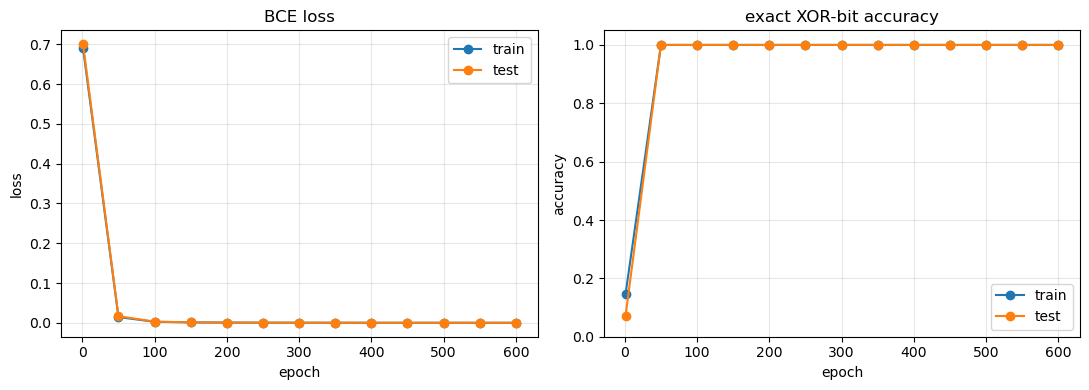

In [9]:
def plot_xor_training(history):
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", label="train")
    axes[0].plot(epochs, [row["test_loss"] for row in history], marker="o", label="test")
    axes[0].set_title("BCE loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_exact_accuracy"] for row in history], marker="o", label="train")
    axes[1].plot(epochs, [row["test_exact_accuracy"] for row in history], marker="o", label="test")
    axes[1].set_title("exact XOR-bit accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    return fig


plot_xor_training(history);

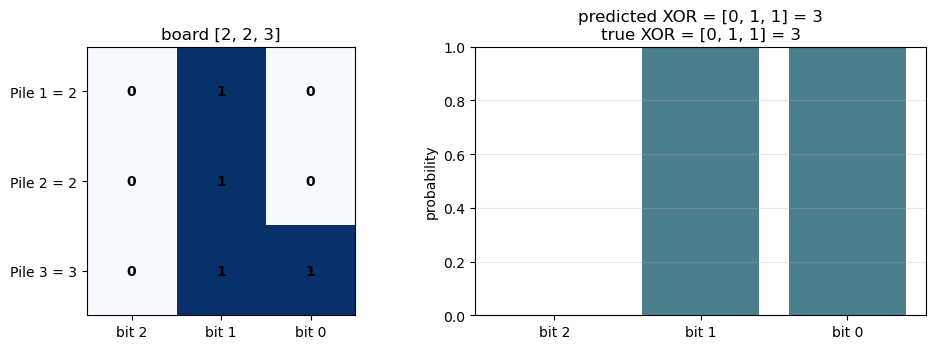

In [10]:
def plot_xor_prediction(model, config, piles):
    result = predict_xor(model, config, piles)
    labels = [f"bit {i}" for i in range(config.bit_width - 1, -1, -1)]

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    axes[0].imshow(board_to_bit_rows(piles, config.bit_width), cmap="Blues", vmin=0, vmax=1)
    axes[0].set_title(f"board {piles}")
    axes[0].set_yticks(range(config.num_piles), [f"Pile {i+1} = {p}" for i, p in enumerate(piles)])
    axes[0].set_xticks(range(config.bit_width), labels)
    for r, row in enumerate(board_to_bit_rows(piles, config.bit_width)):
        for c, value in enumerate(row):
            axes[0].text(c, r, str(value), ha="center", va="center", fontweight="bold")

    axes[1].bar(labels, result["probabilities"], color="#4A7F8B")
    axes[1].set_ylim(0, 1)
    axes[1].set_title(
        f"predicted XOR = {result['bits']} = {result['value']}\n"
        f"true XOR = {result['true_bits']} = {result['true_value']}"
    )
    axes[1].set_ylabel("probability")
    axes[1].grid(axis="y", alpha=0.3)
    fig.tight_layout()
    return fig


plot_xor_prediction(loaded_model, loaded_config, [2, 2, 3]);